# 🏦 FinGuard AI — Anomaly Detection

**Notebook:** 08 — Anomaly Detection

#### Objective
Build an unsupervised anomaly-detection layer using **Isolation Forest** to identify transactions that behave differently from normal transaction patterns.

#### Pipeline
Feature-Engineered Data → Isolation Forest → Anomaly Score → Anomaly Label → Evaluation → Saved Anomaly Model

> This notebook does **not** replace the supervised fraud model from Notebook 07. It adds an independent anomaly signal that will later be consumed by the **Risk Engine**.


#### 1. Environment Setup

In [1]:
import sys
import warnings
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("FinGuard AI — Anomaly Detection")
print("=" * 70)
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)


FinGuard AI — Anomaly Detection
Python : 3.11.15
NumPy  : 2.4.6
Pandas : 3.0.5


#### 2. Project Paths

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Notebooks" else NOTEBOOK_DIR

PROCESSED_DIR = PROJECT_ROOT / "Dataset" / "Processed"
MODEL_DIR = PROJECT_ROOT / "Models"
ANOMALY_MODEL_DIR = MODEL_DIR / "anomaly_model"
REPORT_DIR = PROJECT_ROOT / "Reports"
MODEL_EVAL_DIR = REPORT_DIR / "Model_Evaluation"
FIGURES_DIR = REPORT_DIR / "Figures"

ANOMALY_MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DIR / "feature_engineered_train_balanced.csv"
TEST_PATH = PROCESSED_DIR / "feature_engineered_test.csv"

# Fallbacks for the actual processed files if the feature-engineered
# balanced dataset is unavailable.
if not TRAIN_PATH.exists():
    fallback_train = PROCESSED_DIR / "feature_engineered_train.csv"
    if fallback_train.exists():
        TRAIN_PATH = fallback_train

MODEL_PATH = ANOMALY_MODEL_DIR / "isolation_forest.pkl"
SCORE_PATH = MODEL_EVAL_DIR / "anomaly_detection_results.csv"
SUMMARY_PATH = MODEL_EVAL_DIR / "anomaly_detection_summary.csv"

print("Project Root :", PROJECT_ROOT)
print("Training Data:", TRAIN_PATH)
print("Test Data    :", TEST_PATH)
print("Model Output :", MODEL_PATH)


Project Root : C:\Users\viqua\Desktop\FinGuard AI
Training Data: C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_train_balanced.csv
Test Data    : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
Model Output : C:\Users\viqua\Desktop\FinGuard AI\Models\anomaly_model\isolation_forest.pkl


#### 3. Load Feature-Engineered Data

In [3]:
if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Training dataset not found: {TRAIN_PATH}")

if not TEST_PATH.exists():
    raise FileNotFoundError(f"Test dataset not found: {TEST_PATH}")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("✓ Training data:", train_df.shape)
print("✓ Test data    :", test_df.shape)

display(train_df.head())


✓ Training data: (453204, 54)
✓ Test data    : (56746, 54)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Log1p,Amount_Sqrt,Amount_Squared,Amount_Is_Zero,Amount_Is_High,Time_Day_Index,Time_Hour,Time_Minute,Time_Hour_Sin,Time_Hour_Cos,Time_Day_Sin,Time_Day_Cos,V_Abs_Mean,V_Abs_Max,V_Abs_Std,V_L2_Norm,V_Positive_Count,V_Negative_Count,V_Extreme_Count,Risk_Deviation_Score,Risk_Max_Deviation,Risk_Extreme_Ratio,Risk_Severe_Ratio
0,1.045499,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,1.567867,-0.235685,-0.705588,0.363543,-0.313460,0.285037,-0.577606,0.381516,-0.180758,-0.318110,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,-0.229434,0,3.496508,5.656854,1024.0000,0,0,1,16,9,-0.866025,-0.500000,-0.885292,-0.465035,0.858682,3.565492,0.913525,6.570969,11,17,1,0.858682,3.565492,0.035714,0.0
1,-0.298690,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,-0.482635,1.437124,1.762389,1.254318,0.862657,-0.266203,0.393813,-0.265345,-0.343555,0.392417,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,-0.331197,0,2.078191,2.643861,48.8601,0,0,0,22,25,-0.500000,0.866025,-0.401681,0.915779,0.634595,1.762389,0.507786,4.270568,13,15,0,0.634595,1.762389,0.000000,0.0
2,0.678397,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,-0.497766,1.532977,1.039161,0.475691,-0.689465,0.964112,-0.277525,0.793328,-0.156680,-0.994654,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,-0.298809,0,2.769459,3.866523,223.5025,0,0,1,11,18,0.258819,-0.965926,0.179661,-0.983729,0.620295,2.087997,0.617911,4.591559,17,11,0,0.620295,2.087997,0.000000,0.0
3,-0.074929,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,1.146705,1.337319,-1.775051,2.178843,1.239627,-2.037103,1.344143,-0.475182,0.824830,-1.693484,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,-0.289247,0,2.906901,4.159327,299.2900,0,0,1,1,22,0.258819,0.965926,0.351706,0.936111,0.904225,3.880231,0.885021,6.636381,18,10,1,0.904225,3.880231,0.035714,0.0
4,-1.376728,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,1.492821,1.737807,0.014396,0.329795,-0.044638,0.473131,-0.659717,0.787525,-0.641416,-0.591751,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,-0.261985,0,3.218876,4.898979,576.0000,0,0,0,8,12,0.866025,-0.500000,0.838591,-0.544761,0.673056,2.094285,0.575181,4.649367,13,15,0,0.673056,2.094285,0.000000,0.0


#### 4. Separate Features and Target

In [4]:
TARGET = "Class"

if TARGET not in train_df.columns or TARGET not in test_df.columns:
    raise KeyError(f"Target column '{TARGET}' must exist in both datasets.")

feature_columns = [c for c in train_df.columns if c != TARGET]

missing_in_test = [c for c in feature_columns if c not in test_df.columns]
if missing_in_test:
    raise ValueError(f"Test dataset is missing features: {missing_in_test[:10]}")

X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET].astype(int).copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].astype(int).copy()

# Isolation Forest requires numeric feature values.
non_numeric = X_train.select_dtypes(exclude=np.number).columns.tolist()
if non_numeric:
    raise TypeError(f"Non-numeric features found: {non_numeric}")

print(f"Features: {len(feature_columns)}")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())


Features: 53
Training samples: 453,204
Test samples: 56,746

Training target distribution:
Class
0    226602
1    226602
Name: count, dtype: int64


#### 5. Training Strategy

Isolation Forest is an **unsupervised** anomaly detector.

The target column is therefore **not used during model fitting**. The model learns transaction patterns from the feature matrix and identifies observations that are easier to isolate from the rest of the data.

For a production-style fraud pipeline, the anomaly signal is kept separate from the supervised fraud prediction and will later be combined inside the Risk Engine.


#### 6. Train Isolation Forest

In [5]:
CONTAMINATION = 0.01
RANDOM_STATE = 42
N_ESTIMATORS = 300

print("Training Isolation Forest...")
start = time.time()

isolation_forest = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    max_samples="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

isolation_forest.fit(X_train)

elapsed = time.time() - start

print(f"✓ Training completed in {elapsed:.2f} seconds")
print("Estimators   :", N_ESTIMATORS)
print("Contamination:", CONTAMINATION)


Training Isolation Forest...
✓ Training completed in 20.03 seconds
Estimators   : 300
Contamination: 0.01


#### 7. Generate Anomaly Predictions

In [6]:
# Isolation Forest:
# +1 = normal
# -1 = anomaly
raw_anomaly_labels = isolation_forest.predict(X_test)

anomaly_labels = np.where(raw_anomaly_labels == -1, 1, 0)

# decision_function: higher = more normal.
decision_scores = isolation_forest.decision_function(X_test)

# Convert to an intuitive anomaly score where higher = more anomalous.
anomaly_scores = -decision_scores

results = test_df[[TARGET]].copy()
results["Anomaly_Label"] = anomaly_labels
results["Anomaly_Score"] = anomaly_scores
results["Isolation_Raw_Label"] = raw_anomaly_labels

print("✓ Test anomaly predictions generated")
print("\nAnomaly distribution:")
print(results["Anomaly_Label"].value_counts().sort_index())


✓ Test anomaly predictions generated

Anomaly distribution:
Anomaly_Label
0    56675
1       71
Name: count, dtype: int64


#### 8. Normalize Anomaly Score

In [7]:
score_min = anomaly_scores.min()
score_max = anomaly_scores.max()

if score_max > score_min:
    normalized_scores = (
        (anomaly_scores - score_min) /
        (score_max - score_min)
    ) * 100
else:
    normalized_scores = np.zeros(len(anomaly_scores))

results["Anomaly_Score_100"] = normalized_scores

print("Anomaly score range:")
print(f"Raw       : {anomaly_scores.min():.6f} → {anomaly_scores.max():.6f}")
print(f"Normalized: {normalized_scores.min():.2f} → {normalized_scores.max():.2f}")


Anomaly score range:
Raw       : -0.244411 → 0.109390
Normalized: 0.00 → 100.00


#### 9. Compare Anomalies With Actual Fraud Labels

In [8]:
cm = confusion_matrix(y_test, anomaly_labels, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix — Anomaly Detector")
print("=" * 50)
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        anomaly_labels,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

try:
    roc_auc = roc_auc_score(y_test, anomaly_scores)
    pr_auc = average_precision_score(y_test, anomaly_scores)
except ValueError:
    roc_auc = np.nan
    pr_auc = np.nan

print(f"ROC-AUC: {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC: Not Available")
print(f"PR-AUC : {pr_auc:.4f}" if not np.isnan(pr_auc) else "PR-AUC : Not Available")


Confusion Matrix — Anomaly Detector
True Negative : 56582
False Positive: 69
False Negative: 93
True Positive : 2

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.03      0.02      0.02        95

    accuracy                           1.00     56746
   macro avg       0.51      0.51      0.51     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.8902
PR-AUC : 0.0205


#### 10. Anomaly Detection Summary

In [9]:
anomaly_count = int((anomaly_labels == 1).sum())
normal_count = int((anomaly_labels == 0).sum())

summary = pd.DataFrame([{
    "Model": "Isolation Forest",
    "Training_Samples": len(X_train),
    "Test_Samples": len(X_test),
    "Features": len(feature_columns),
    "Estimators": N_ESTIMATORS,
    "Contamination": CONTAMINATION,
    "Detected_Anomalies": anomaly_count,
    "Detected_Normal": normal_count,
    "Anomaly_Rate_Percent": anomaly_count / len(X_test) * 100,
    "ROC_AUC": roc_auc,
    "PR_AUC": pr_auc
}])

display(summary)


,Model,Training_Samples,Test_Samples,Features,Estimators,Contamination,Detected_Anomalies,Detected_Normal,Anomaly_Rate_Percent,ROC_AUC,PR_AUC
0,Isolation Forest,453204,56746,53,300,0.01,71,56675,0.125119,0.890221,0.020472


#### 11. Anomaly Score Distribution

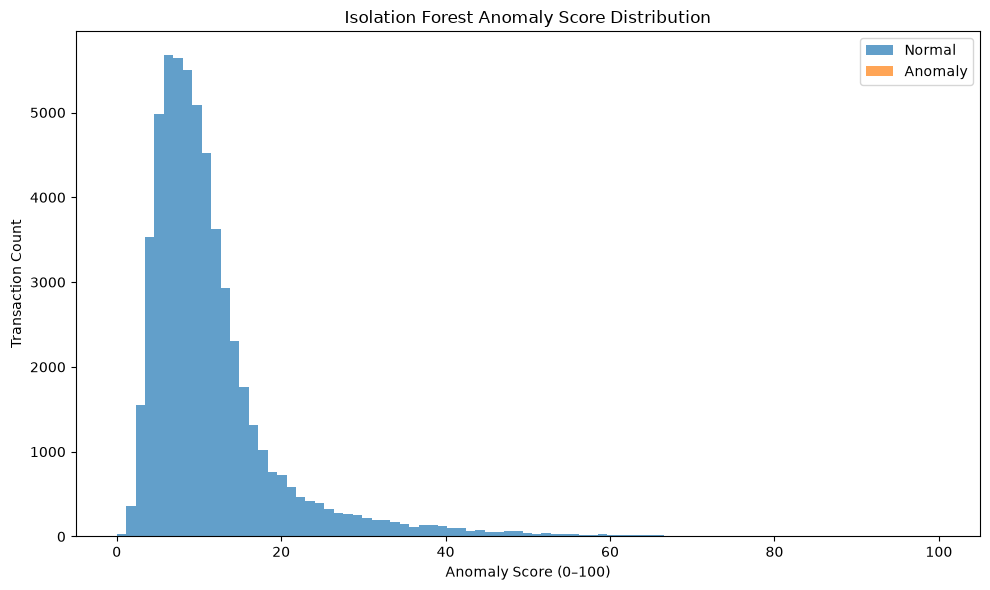

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(
    results.loc[results["Anomaly_Label"] == 0, "Anomaly_Score_100"],
    bins=60,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    results.loc[results["Anomaly_Label"] == 1, "Anomaly_Score_100"],
    bins=60,
    alpha=0.7,
    label="Anomaly"
)

plt.xlabel("Anomaly Score (0–100)")
plt.ylabel("Transaction Count")
plt.title("Isolation Forest Anomaly Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()


#### 12. Actual Fraud vs Detected Anomaly

Detected_Anomaly,0,1
Actual_Fraud,,
0,56582,69
1,93,2


<Figure size 800x500 with 0 Axes>

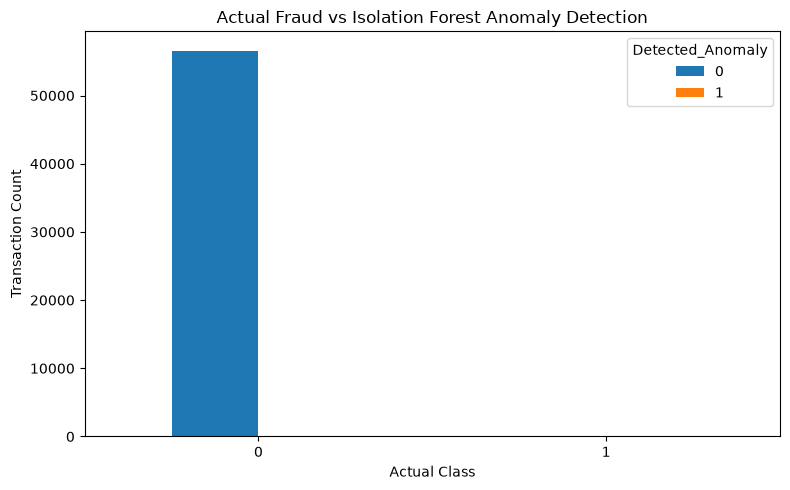

In [11]:
comparison = pd.crosstab(
    y_test.rename("Actual_Fraud"),
    pd.Series(anomaly_labels, name="Detected_Anomaly")
)

display(comparison)

plt.figure(figsize=(8, 5))
comparison.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Actual Class")
plt.ylabel("Transaction Count")
plt.title("Actual Fraud vs Isolation Forest Anomaly Detection")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### 13. Highest Anomaly Transactions

In [12]:
top_anomalies = results.sort_values(
    "Anomaly_Score_100",
    ascending=False
).head(25).copy()

display(top_anomalies)


,Class,Anomaly_Label,Anomaly_Score,Isolation_Raw_Label,Anomaly_Score_100
40433,0,1,0.109390,-1,100.000000
45550,0,1,0.095069,-1,95.952242
41549,0,1,0.086923,-1,93.649795
34096,0,1,0.083111,-1,92.572328
42028,0,1,0.078962,-1,91.399674
47018,0,1,0.078937,-1,91.392657
8671,1,1,0.072209,-1,89.490769
42774,0,1,0.071690,-1,89.344119
42257,0,1,0.068949,-1,88.569462
25221,0,1,0.063856,-1,87.129980


#### 14. Fraud Rate Among Detected Anomalies

In [13]:
fraud_rate_anomalies = (
    y_test[anomaly_labels == 1].mean() * 100
    if anomaly_count > 0
    else 0
)

fraud_rate_normal = (
    y_test[anomaly_labels == 0].mean() * 100
    if normal_count > 0
    else 0
)

print(f"Fraud rate among detected anomalies : {fraud_rate_anomalies:.4f}%")
print(f"Fraud rate among detected normal     : {fraud_rate_normal:.4f}%")


Fraud rate among detected anomalies : 2.8169%
Fraud rate among detected normal     : 0.1641%


#### 15. Save Anomaly Detection Results

In [14]:
# Save the full test-level anomaly output for downstream Risk Engine use.
results_to_save = test_df.copy()

results_to_save["Anomaly_Label"] = anomaly_labels
results_to_save["Anomaly_Score"] = anomaly_scores
results_to_save["Anomaly_Score_100"] = normalized_scores

results_to_save.to_csv(SCORE_PATH, index=False)
summary.to_csv(SUMMARY_PATH, index=False)

joblib.dump(isolation_forest, MODEL_PATH)

# Save metadata alongside the model.
metadata = {
    "model": "IsolationForest",
    "target_column": TARGET,
    "feature_columns": feature_columns,
    "n_features": len(feature_columns),
    "n_estimators": N_ESTIMATORS,
    "contamination": CONTAMINATION,
    "random_state": RANDOM_STATE,
    "score_definition": "negative decision_function; higher = more anomalous",
    "normalized_score_definition": "min-max anomaly score scaled to 0-100",
    "training_samples": len(X_train),
    "test_samples": len(X_test)
}

joblib.dump(
    metadata,
    ANOMALY_MODEL_DIR / "isolation_forest_metadata.pkl"
)

print("✓ Model saved:", MODEL_PATH)
print("✓ Results saved:", SCORE_PATH)
print("✓ Summary saved:", SUMMARY_PATH)
print("✓ Metadata saved:", ANOMALY_MODEL_DIR / "isolation_forest_metadata.pkl")


✓ Model saved: C:\Users\viqua\Desktop\FinGuard AI\Models\anomaly_model\isolation_forest.pkl
✓ Results saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\anomaly_detection_results.csv
✓ Summary saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\anomaly_detection_summary.csv
✓ Metadata saved: C:\Users\viqua\Desktop\FinGuard AI\Models\anomaly_model\isolation_forest_metadata.pkl


#### 16. Reload Model and Validate

In [15]:
loaded_anomaly_model = joblib.load(MODEL_PATH)

reloaded_labels_raw = loaded_anomaly_model.predict(X_test)
reloaded_labels = np.where(reloaded_labels_raw == -1, 1, 0)

if not np.array_equal(anomaly_labels, reloaded_labels):
    raise ValueError("Reloaded anomaly model produced different labels.")

print("✓ Saved Isolation Forest successfully reloaded")
print("✓ Prediction consistency check passed")


✓ Saved Isolation Forest successfully reloaded
✓ Prediction consistency check passed


#### 17. Final Notebook Validation

In [16]:
required_outputs = [
    MODEL_PATH,
    ANOMALY_MODEL_DIR / "isolation_forest_metadata.pkl",
    SCORE_PATH,
    SUMMARY_PATH
]

print("Output Validation")
print("=" * 60)

for path in required_outputs:
    print(
        ("✓ EXISTS" if Path(path).exists() else "✗ MISSING").ljust(12),
        Path(path)
    )

if not all(Path(path).exists() for path in required_outputs):
    raise RuntimeError("One or more anomaly-detection outputs are missing.")

print("\n✓ Notebook 08 validation completed successfully")


Output Validation
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\anomaly_model\isolation_forest.pkl
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\anomaly_model\isolation_forest_metadata.pkl
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\anomaly_detection_results.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\anomaly_detection_summary.csv

✓ Notebook 08 validation completed successfully


#### 18. Handoff to Notebook 09 — Risk Engine

Notebook 08 now provides the anomaly layer required by the next stage.

##### Saved outputs

- `Models/anomaly_model/isolation_forest.pkl`
- `Models/anomaly_model/isolation_forest_metadata.pkl`
- `Reports/Model_Evaluation/anomaly_detection_results.csv`
- `Reports/Model_Evaluation/anomaly_detection_summary.csv`

##### Next Notebook

**09_Risk_Engine.ipynb**

The Risk Engine will combine:

**Supervised Fraud Probability + Anomaly Score + Risk Rules → Final Risk Score → Low / Medium / High Risk**

The anomaly detector is therefore an additional signal, **not the final fraud decision**.


#### 19. Completion Summary

In [17]:
print("=" * 75)
print("FIN GUARD AI — ANOMALY DETECTION COMPLETED")
print("=" * 75)
print("✓ Model              : Isolation Forest")
print(f"✓ Features           : {len(feature_columns)}")
print(f"✓ Test Samples       : {len(X_test):,}")
print(f"✓ Detected Anomalies : {anomaly_count:,}")
print(f"✓ Anomaly Rate       : {anomaly_count / len(X_test) * 100:.4f}%")
print(f"✓ ROC-AUC            : {roc_auc:.4f}" if not np.isnan(roc_auc) else "✓ ROC-AUC            : Not Available")
print(f"✓ PR-AUC             : {pr_auc:.4f}" if not np.isnan(pr_auc) else "✓ PR-AUC             : Not Available")
print("✓ Model Artifact     : Saved")
print("✓ Results Artifact   : Saved")
print("=" * 75)


FIN GUARD AI — ANOMALY DETECTION COMPLETED
✓ Model              : Isolation Forest
✓ Features           : 53
✓ Test Samples       : 56,746
✓ Detected Anomalies : 71
✓ Anomaly Rate       : 0.1251%
✓ ROC-AUC            : 0.8902
✓ PR-AUC             : 0.0205
✓ Model Artifact     : Saved
✓ Results Artifact   : Saved
